In [ ]:
import tensorflow as tf
print("GPU:", tf.config.list_physical_devices('GPU'))

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
!pip install transformers imbalanced-learn -q

In [ ]:
!pip install transformers torch imbalanced-learn -q
print("Done!")

Done!


In [ ]:
import os
os.kill(os.getpid(), 9)

In [ ]:
import torch
print(f"PyTorch : {torch.__version__}")
print(f"GPU     : {torch.cuda.is_available()}")

PyTorch : 2.11.0+cu128
GPU     : True


In [ ]:
import pandas as pd
import numpy as np
import re
import torch
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
from transformers import BertTokenizerFast, BertForSequenceClassification
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import get_scheduler

device = torch.device('cuda')

In [ ]:
from google.colab import files
uploaded=files.upload()

Saving complaints.csv.csv to complaints.csv.csv


In [8]:
def load_and_clean(filepath='complaints.csv.csv', n_classes=5):
    df = pd.read_csv(filepath)
    print(f"Raw rows loaded: {len(df)}")

    df = df[['narrative', 'product']].copy()
    df.columns = ['text', 'label']

    df = df[df['text'].notna()]
    df = df[df['text'].str.strip() != '']
    df = df[df['label'].notna()]

    top_categories = df['label'].value_counts().nlargest(n_classes).index
    df = df[df['label'].isin(top_categories)]

    def clean(text):
        text = str(text).lower()
        text = re.sub(r'x{2,}', '', text)
        text = re.sub(r'[^a-zA-Z\s]', '', text)
        text = re.sub(r'\s+', ' ', text).strip()
        return text

    df['text'] = df['text'].apply(clean)
    df = df[df['text'].str.split().str.len() > 10]

    le = LabelEncoder()
    df['label'] = le.fit_transform(df['label'])
    num_classes = len(le.classes_)

    print(f"\nBefore balancing:")
    print(df['label'].value_counts())

    under_strategy = {}
    for cls in df['label'].unique():
        count = df['label'].value_counts()[cls]
        under_strategy[cls] = min(count, 10000)

    under = RandomUnderSampler(sampling_strategy=under_strategy, random_state=42)
    X_res, y_res = under.fit_resample(
        df['text'].values.reshape(-1, 1), df['label']
    )

    over_strategy = {}
    unique, counts = np.unique(y_res, return_counts=True)
    for cls, count in zip(unique, counts):
        if count < 8000:
            over_strategy[cls] = 8000

    over = RandomOverSampler(sampling_strategy=over_strategy, random_state=42)
    X_bal, y_bal = over.fit_resample(X_res, y_res)

    df_balanced = pd.DataFrame({
        'text':  X_bal.flatten(),
        'label': y_bal
    })

    print(f"\nAfter balancing:")
    print(df_balanced['label'].value_counts())
    print(f"Classes: {list(le.classes_)}")
    print(f"Total  : {len(df_balanced)}")

    return df_balanced, num_classes, le

df_balanced, num_classes, le = load_and_clean()

Raw rows loaded: 162421

Before balancing:
label
1    83668
2    21870
3    18669
0    15255
4    12570
Name: count, dtype: int64

After balancing:
label
0    10000
1    10000
2    10000
3    10000
4    10000
Name: count, dtype: int64
Classes: ['credit_card', 'credit_reporting', 'debt_collection', 'mortgages_and_loans', 'retail_banking']
Total  : 50000


In [10]:
X_train,X_test,y_train,y_test=train_test_split(
    df_balanced['text'],df_balanced['label'],test_size=0.2,random_state=42,stratify=df_balanced['label'])
X_train,X_val,y_train,y_val=train_test_split(
    X_train,y_train,test_size=0.1,random_state=42)
print(f"Train : {len(X_train)}")
print(f"Val   : {len(X_val)}")
print(f"Test   : {len(X_test)}")

Train : 36000
Val   : 4000
Test   : 10000


In [11]:
print("loading BERT Tokenizer")
bert_tokenizer=BertTokenizerFast.from_pretrained('bert-base-uncased')
print("Tokenizer Loaded")

loading BERT Tokenizer


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizer Loaded


In [13]:
MAX_LEN = 128

class CFPBDataset(Dataset):
    def __init__(self, texts, labels):
        self.encodings = bert_tokenizer(
            list(texts),
            truncation=True,
            padding=True,
            max_length=MAX_LEN,
            return_tensors='pt'
        )
        self.labels = torch.tensor(list(labels), dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids':      self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels':         self.labels[idx]
        }

print("Creating datasets...")
train_dataset = CFPBDataset(X_train, y_train)
val_dataset   = CFPBDataset(X_val,   y_val)
test_dataset  = CFPBDataset(X_test,  y_test)

BATCH_SIZE   = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

Creating datasets...
Train batches : 2250
Val batches   : 250
Test batches  : 625


In [14]:
def train_bert(model, train_loader, val_loader, epochs=3, lr=2e-5):
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    num_steps = len(train_loader) * epochs
    warmup    = num_steps // 10

    scheduler = get_scheduler(
        'linear',
        optimizer=optimizer,
        num_warmup_steps=warmup,
        num_training_steps=num_steps
    )

    history = {'train_acc': [], 'val_acc': [],
               'train_loss': [], 'val_loss': []}

    for epoch in range(epochs):
        # Training
        model.train()
        total_loss, correct, total = 0, 0, 0

        for batch in train_loader:
            batch   = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            loss    = outputs.loss
            preds   = outputs.logits.argmax(dim=1)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

            total_loss += loss.item()
            correct    += (preds == batch['labels']).sum().item()
            total      += batch['labels'].size(0)

        train_acc  = correct / total
        train_loss = total_loss / len(train_loader)

        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0

        with torch.no_grad():
            for batch in val_loader:
                batch   = {k: v.to(device) for k, v in batch.items()}
                outputs = model(**batch)
                preds   = outputs.logits.argmax(dim=1)

                val_loss    += outputs.loss.item()
                val_correct += (preds == batch['labels']).sum().item()
                val_total   += batch['labels'].size(0)

        val_acc  = val_correct / val_total
        val_loss = val_loss / len(val_loader)

        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    return history

In [15]:
print("Loading BERT...")
bert_default = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=num_classes
).to(device)

print("Training default BERT...")
history1 = train_bert(bert_default, train_loader, val_loader, epochs=3, lr=2e-5)

Loading BERT...


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training default BERT...
Epoch 1/3 | Train Loss: 0.6629 | Train Acc: 0.7573 | Val Loss: 0.4258 | Val Acc: 0.8558
Epoch 2/3 | Train Loss: 0.3750 | Train Acc: 0.8748 | Val Loss: 0.4091 | Val Acc: 0.8720
Epoch 3/3 | Train Loss: 0.2739 | Train Acc: 0.9134 | Val Loss: 0.4232 | Val Acc: 0.8712


In [16]:
def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            batch  = {k: v.to(device) for k, v in batch.items()}
            preds  = model(**batch).logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch['labels'].cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='macro')
    return acc, f1, all_preds, all_labels

acc_default, f1_default, preds_default, labels = evaluate(bert_default, test_loader)

print("BERT DEFAULT RESULTS")
print(f"Accuracy : {acc_default:.4f}")
print(f"F1 Score : {f1_default:.4f}")
print(classification_report(labels, preds_default, target_names=le.classes_))

BERT DEFAULT RESULTS
Accuracy : 0.8743
F1 Score : 0.8743
                     precision    recall  f1-score   support

        credit_card       0.84      0.86      0.85      2000
   credit_reporting       0.87      0.85      0.86      2000
    debt_collection       0.86      0.86      0.86      2000
mortgages_and_loans       0.90      0.89      0.90      2000
     retail_banking       0.90      0.91      0.91      2000

           accuracy                           0.87     10000
          macro avg       0.87      0.87      0.87     10000
       weighted avg       0.87      0.87      0.87     10000



In [17]:
print("Loading fine tuned BERT...")
bert_ft = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=num_classes
).to(device)

print("Training fine tuned BERT...")
history2 = train_bert(
    bert_ft,
    train_loader,
    val_loader,
    epochs=2,
    lr=2e-5
)

Loading fine tuned BERT...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training fine tuned BERT...
Epoch 1/2 | Train Loss: 0.6291 | Train Acc: 0.7753 | Val Loss: 0.4323 | Val Acc: 0.8592
Epoch 2/2 | Train Loss: 0.3594 | Train Acc: 0.8830 | Val Loss: 0.4000 | Val Acc: 0.8700


In [18]:
acc_ft, f1_ft, preds_ft, labels = evaluate(bert_ft, test_loader)

print("BERT FINE TUNED RESULTS")
print(f"Accuracy : {acc_ft:.4f}")
print(f"F1 Score : {f1_ft:.4f}")
print(classification_report(labels, preds_ft, target_names=le.classes_))

BERT FINE TUNED RESULTS
Accuracy : 0.8747
F1 Score : 0.8747
                     precision    recall  f1-score   support

        credit_card       0.84      0.87      0.85      2000
   credit_reporting       0.87      0.86      0.86      2000
    debt_collection       0.87      0.86      0.86      2000
mortgages_and_loans       0.90      0.88      0.89      2000
     retail_banking       0.90      0.91      0.90      2000

           accuracy                           0.87     10000
          macro avg       0.87      0.87      0.87     10000
       weighted avg       0.87      0.87      0.87     10000



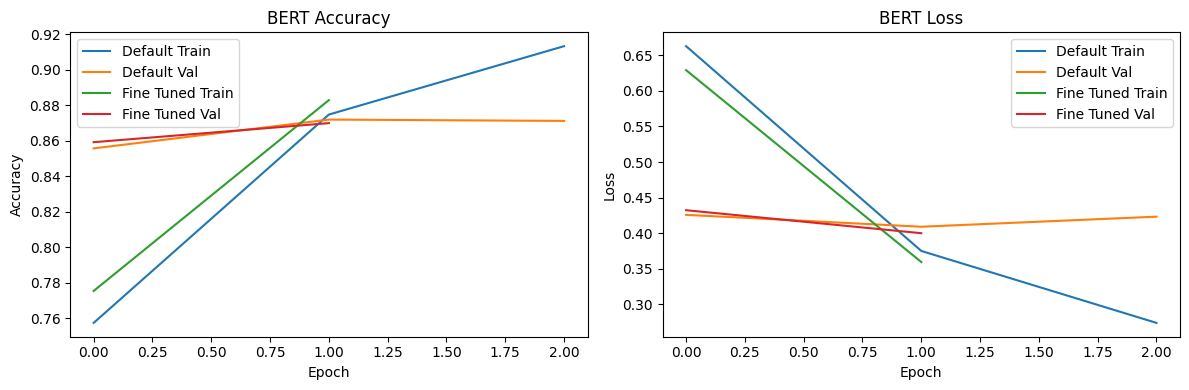

In [19]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history1['train_acc'], label='Default Train')
plt.plot(history1['val_acc'],   label='Default Val')
plt.plot(history2['train_acc'], label='Fine Tuned Train')
plt.plot(history2['val_acc'],   label='Fine Tuned Val')
plt.title('BERT Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history1['train_loss'], label='Default Train')
plt.plot(history1['val_loss'],   label='Default Val')
plt.plot(history2['train_loss'], label='Fine Tuned Train')
plt.plot(history2['val_loss'],   label='Fine Tuned Val')
plt.title('BERT Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('bert_training_curves.png')
plt.show()

In [20]:
import shutil
from google.colab import files

# Save model
bert_ft.save_pretrained('bert_model')
bert_tokenizer.save_pretrained('bert_model')

print("Model saved!")

# Zip and download
shutil.make_archive('bert_model', 'zip', 'bert_model')
files.download('bert_model.zip')

print("Downloaded! Put in:")
print("C:/Users/mpree/cfpb-classifier/saved_models/bert_model/")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded! Put in:
C:/Users/mpree/cfpb-classifier/saved_models/bert_model/
